Q - 1 : Read house price dataset. scale the features the dataset using scaler and implement lasso regression with a high alpha value to demostrate feature selection, identifying which coefficients were reduced to exactly zero.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
data = datasets.fetch_california_housing()

In [3]:
X = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

In [4]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

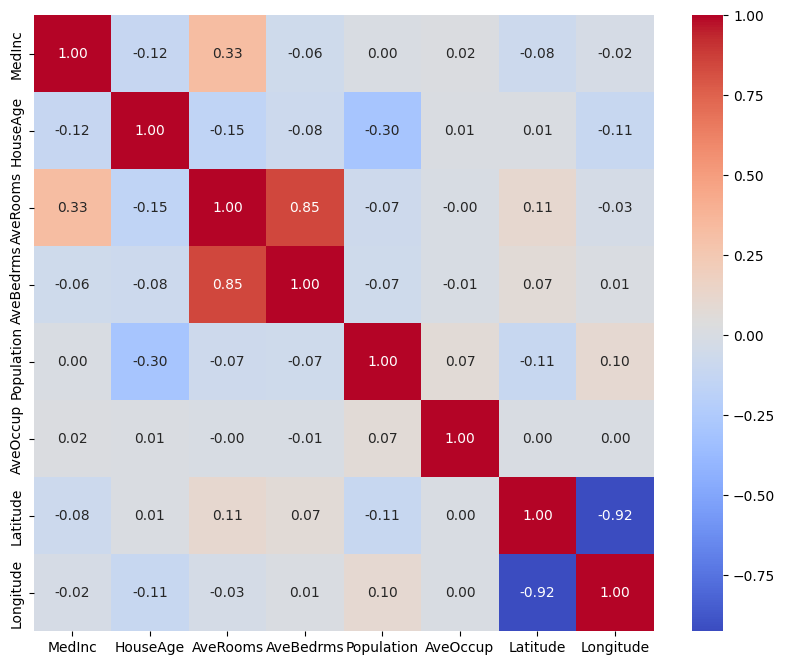

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f",cmap = "coolwarm")
plt.show()

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from re import L
from sklearn.linear_model import Ridge,LinearRegression,Lasso

linear = LinearRegression()
linear.fit(X_train_scaled,y_train)

ridge_strong = Ridge(alpha=500)
lasso_strong = Lasso(alpha=0.01)

ridge_strong.fit(X_train_scaled,y_train)
lasso_strong.fit(X_train_scaled,y_train)

comparison = pd.DataFrame({
    "Features": X_train.columns,
    "Linear": linear.coef_,
    "Ridge": ridge_strong.coef_,
    "Lasso": lasso_strong.coef_
})

Q - 2 : Read the std_marks.csv dataset and handle missing values. Define multiple predictor variables and a single target variable to train a Multiple Linear Regression model with an 80:20 split and evaluate the final predictions using the Mean Squared error metric

In [10]:
std_data = pd.read_csv("dataset/std_marks_data.csv")

In [11]:
std_data

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [12]:
std_data.isna().sum()

hours       12
age          0
internet     0
marks        0
dtype: int64

In [13]:
std_data.hours=std_data.hours.fillna(std_data.hours.mean())

In [14]:
std_data.isna().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [15]:
X = std_data.iloc[:,:-1]

In [16]:
X

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [17]:
y = std_data.iloc[:,-1]

In [18]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [19]:
X_test.shape

(60, 3)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LinearRegression()
model.fit(X_train,y_train)
print("Intercept=",model.intercept_,"\nCoefficient:",model.coef_)

Intercept= 57.28235913570198 
Coefficient: [1.20868075 0.34520037 3.76590959]
